In [1]:
import os
import json
import pandas as pd
# from datetime import datetime
from dotenv import load_dotenv

from options import OptionSurface, Deribit, OKX, Bybit
from portfolio_management import Portfolio
from api_client import TradingDeskAPI
# from scanner import MarketScanner

In [2]:
# Initialize all classes and parameters

load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
# load_dotenv(r"C:/Users/brian/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
DATA_DIR = os.getenv("DATA_DIR")
FRACTION = float(os.getenv("FRACTION"))
MAX_POSITION = float(os.getenv("MAX_POSITION"))
ENTRY_EV_THRESHOLD = float(os.getenv("ENTRY_EV_THRESHOLD")) # require 1% edge, default = 0
EXIT_EV_THRESHOLD = float(os.getenv("EXIT_EV_THRESHOLD"))
print(BASE_URL)

with open(f"{DATA_DIR}/crypto_tag_ids.json", "r") as f:
    crypto_tag_ids = set(json.load(f))

s = OptionSurface()
portfolio = Portfolio()
api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
# scanner = MarketScanner1(api=api)

# target_expiry_str = "25DEC26"
# target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")

currencies = ["BTC", "ETH"]
# currencies = ["BTC", "ETH", "HYPE", "SOL", "ZEC"]

https://alphasignal-dev.moretoncp.com


In [3]:
# 9. Get current markets
all_markets_df = api.get_all_markets(DATA_DIR=DATA_DIR, count_limit=30, liquidity_num_min=10000, volume_num_min=5000)
all_markets_df.head()

Fetched 100 markets | Total: 100
Fetched 100 markets | Total: 200
Fetched 100 markets | Total: 300
Fetched 100 markets | Total: 400
Fetched 100 markets | Total: 500
Fetched 100 markets | Total: 600
Fetched 100 markets | Total: 700
Fetched 100 markets | Total: 800
Fetched 100 markets | Total: 900
Fetched 100 markets | Total: 1,000
Fetched 100 markets | Total: 1,100
Fetched 100 markets | Total: 1,200
Fetched 100 markets | Total: 1,300
Fetched 100 markets | Total: 1,400
Fetched 100 markets | Total: 1,500
Fetched 100 markets | Total: 1,600
Fetched 100 markets | Total: 1,700
Fetched 100 markets | Total: 1,800
Fetched 100 markets | Total: 1,900
Fetched 100 markets | Total: 2,000
Fetched 100 markets | Total: 2,100
Fetched 100 markets | Total: 2,200
Fetched 100 markets | Total: 2,300
Fetched 100 markets | Total: 2,400
Fetched 100 markets | Total: 2,500
Fetched 100 markets | Total: 2,600
Fetched 100 markets | Total: 2,700
Fetched 100 markets | Total: 2,800
Fetched 100 markets | Total: 2,900
Fet

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,showGmpOutcome,umaResolutionStatus,oneHourPriceChange,eventStartTime,gameStartTime,groupItemRange,secondsDelay,sportsMarketType,line,marketMetadata
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31T00:00:00Z,193190.05922,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,367292.38378,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07T00:00:00Z,373771.32926,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07T00:00:00Z,558886.66268,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,508091.22644,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import re

def has_matching_tag(tags):
    if tags is None:
        return False

    return any(
        tag.get("label", "").strip().lower() in keywords
        for tag in tags
        if isinstance(tag, dict)
    )

cutoff = pd.Timestamp("2027-10-15", tz="UTC")
now = pd.Timestamp.now(tz="UTC")

all_markets_df["endDate"] = pd.to_datetime(all_markets_df["endDate"], utc=True)
filtered_df = all_markets_df[(all_markets_df["endDate"] < cutoff) & (all_markets_df["endDate"] > now)]

keywords = [
    "weather"
]

pattern = "|".join(map(re.escape, keywords))

mask = (
    filtered_df["question"].fillna("").str.contains(pattern, case=False, regex=True)
    | filtered_df["description"].fillna("").str.contains(pattern, case=False, regex=True)
    | filtered_df["tags"].apply(has_matching_tag)
)

matches = filtered_df.loc[mask].copy()
matches

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,showGmpOutcome,umaResolutionStatus,oneHourPriceChange,eventStartTime,gameStartTime,groupItemRange,secondsDelay,sportsMarketType,line,marketMetadata
602,678686,Will 2026 be the hottest year on record?,0xe67f4d31f0eba1b009b49d7a7739b2a5f53a2d7d979a...,will-2026-be-the-hottest-year-on-record,,2026-12-31 00:00:00+00:00,13320.6688,2025-11-12T22:46:10.824175Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,678688,Will 2026 be the third-hottest year on record?,0x77e931cce8473e1b380bd4457a54d5948d3739894169...,will-2026-be-the-third-hottest-year-on-record,,2026-12-31 00:00:00+00:00,34196.9981,2025-11-12T22:46:13.177115Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604,678689,Will 2026 be the fourth-hottest year on record?,0x6c8a4426ea2278ce7936c770cbf4d66ad2dead1c8ee5...,will-2026-be-the-fourth-hottest-year-on-record,,2026-12-31 00:00:00+00:00,33397.54997,2025-11-12T22:46:12.92156Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
605,678690,Will 2026 be the fifth-hottest year on record?,0xecf2f4f2222e3393545e73f6ed219065c6bfa5c66db5...,will-2026-be-the-fifth-hottest-year-on-record,,2026-12-31 00:00:00+00:00,34153.29221,2025-11-12T22:46:15.012828Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
606,678691,Will 2026 rank as the sixth-hottest year on re...,0x284c11566675c2764eeca776d2e0834fefc1430514b7...,will-2026-rank-as-the-sixth-hottest-year-on-re...,,2026-12-31 00:00:00+00:00,21246.21967,2025-11-12T22:46:27.791346Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
964,897843,9.0 or above earthquake before 2027?,0x234cb84f9e92194f93c6df4990e7e52c6948ec4d6140...,9pt0-or-above-earthquake-before-2027,,2026-12-31 00:00:00+00:00,17976.56591,2025-12-08T23:21:39.772783Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
965,897844,10.0 or above earthquake before 2027?,0x16df76a155e148ef925c2a808204d5f2e2ac68d95853...,10pt0-or-above-earthquake-before-2027,,2026-12-31 00:00:00+00:00,31550.93169,2025-12-08T23:21:39.517214Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1002,902977,Will there be another US government shutdown b...,0x9317b943475e9d550402f328a1ea9cb5f69a616ffd47...,will-there-be-another-us-government-shutdown-b...,NaN,2026-11-03 00:00:00+00:00,15476.76783,2025-12-09T18:47:58.018597Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1003,902978,Will there be another US government shutdown b...,0x02df71403f5136e9c803231cb8e2333a1b9f575bb517...,will-there-be-another-us-government-shutdown-b...,NaN,2026-11-03 00:00:00+00:00,16554.20391,2025-12-09T18:47:59.484216Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,-0.0015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1196,1073790,Will there be between 8 and 10 earthquakes of ...,0x30e551d38cf2cd4e254f3545f17a9b3d55a9d8781e85...,will-there-be-between-8-and-10-earthquakes-of-...,NaN,2026-12-31 00:00:00+00:00,67559.43021,2025-12-31T17:12:34.91319Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,proposed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import re
import json
import calendar
import numpy as np
import pandas as pd
from dateutil import parser
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor

class MarketScanner1:

    def __init__(self, api):
        self.api = api


    def scan_market(self, markets_df):

        markets_df = markets_df[
            (markets_df["acceptingOrders"] == True) &
            (markets_df["enableOrderBook"] == True)
        ]

        markets_df["tokens"] = markets_df["clobTokenIds"].apply(json.loads)
        markets_df["yes_token"] = markets_df["tokens"].apply(lambda x: x[0])
        markets_df["no_token"] = markets_df["tokens"].apply(lambda x: x[1])

        markets_df["outcomePrices"] = markets_df["outcomePrices"].apply(json.loads)
        markets_df["yes_price"] = markets_df["outcomePrices"].apply(lambda x: float(x[0]))
        markets_df["no_price"] = markets_df["outcomePrices"].apply(lambda x: float(x[1]))

        markets_df["yes_bid_est"] = markets_df["yes_price"] - markets_df["spread"] / 2
        markets_df["yes_ask_est"] = markets_df["yes_price"] + markets_df["spread"] / 2
        markets_df["no_bid_est"] = markets_df["no_price"] - markets_df["spread"] / 2
        markets_df["no_ask_est"] = markets_df["no_price"] + markets_df["spread"] / 2

        book_cols = [
            "yes_book",
            "no_book",
            "yes_bid",
            "yes_ask",
            "no_bid",
            "no_ask",
        ]

        with ThreadPoolExecutor(max_workers=30) as executor:
            markets_df[book_cols] = list(executor.map(
                self.get_books, (row for _, row in markets_df.iterrows())))

        return markets_df

    def get_books(self, row):
    
        yes_book = self.api.orderbook(row["yes_token"])
        no_book = self.api.orderbook(row["no_token"])

        yes_bids = yes_book.get("bids", [])
        yes_asks = yes_book.get("asks", [])

        no_bids = no_book.get("bids", [])
        no_asks = no_book.get("asks", [])

        return pd.Series({
            "yes_book": yes_book,
            "no_book": no_book,

            # Highest price someone is bidding
            "yes_bid": (max(float(x["price"]) for x in yes_bids) if yes_bids else None),

            # Lowest price someone is asking
            "yes_ask": (min(float(x["price"]) for x in yes_asks) if yes_asks else None),

            # Highest price someone is bidding
            "no_bid": (max(float(x["price"]) for x in no_bids) if no_bids else None),

            # Lowest price someone is asking
            "no_ask": (min(float(x["price"]) for x in no_asks) if no_asks else None)
        })

scanner = MarketScanner1(api=api)
markets_df = scanner.scan_market(all_markets_df)
markets_df

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,marketMetadata,tokens,yes_token,no_token,yes_price,no_price,yes_bid_est,yes_ask_est,no_bid_est,no_ask_est
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31 00:00:00+00:00,193190.05922,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[323382201900713514357728017797253022445757752...,3233822019007135143577280177972530224457577521...,2565931067499367556234575966511475989240002624...,0.0425,0.9575,0.042,0.043,0.957,0.958
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07 00:00:00+00:00,367292.38378,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[545330438199465925475175111769409999556338601...,5453304381994659254751751117694099995563386012...,8785417414807465206046792108118140235746730372...,0.1465,0.8535,0.146,0.147,0.853,0.854
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07 00:00:00+00:00,373771.32926,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[107064985435494333113391038470401719113272800...,1070649854354943331133910384704017191132728005...,6517607226132473785608568807162711850954929392...,0.2095,0.7905,0.209,0.210,0.790,0.791
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07 00:00:00+00:00,558886.66268,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[910312791719819591973617101272135771025768265...,9103127917198195919736171012721357710257682651...,1849406552792407375021723776578438036543031939...,0.0525,0.9475,0.052,0.053,0.947,0.948
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07 00:00:00+00:00,508091.22644,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[711698394974205962858418475141235898478934157...,7116983949742059628584184751412358984789341575...,5529082759955328024596317572494049675355772243...,0.0505,0.9495,0.050,0.051,0.949,0.950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2487206,Next Mythos-Class Model released by September ...,0x0ca328688c590d82b80ec763d0a34353b9b9bd56dd20...,next-mythos-class-model-released-by-september-...,,2026-09-30 03:59:00+00:00,10232.6532,2026-06-10T15:12:01.955Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,[874647514465095853783905124367441573143150793...,8746475144650958537839051243674415731431507935...,1094806035104303652577438323970587020896569471...,0.9200,0.0800,0.910,0.930,0.070,0.090
2996,2487274,Another critical Cloudflare incident by August...,0x5856328392136a28db888aa672f6d16cc12d7728c004...,another-critical-cloudflare-incident-by-august...,,2026-09-01 03:59:00+00:00,11910.63277,2026-06-11T13:52:13.202942Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,[106558919554284263511666341283706816209398247...,1065589195542842635116663412837068162093982472...,6904194240417753362081467591080279927027085353...,0.0995,0.9005,0.079,0.120,0.880,0.921
2997,2487478,Will Daniel Vilela win the Governor of Goiás e...,0x34e779bcb09867f7a5e1a90f69e469dd18bc8e8050a5..

In [8]:
markets_df[markets_df["spread"] > 0.05]

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,marketMetadata,tokens,yes_token,no_token,yes_price,no_price,yes_bid_est,yes_ask_est,no_bid_est,no_ask_est
516,666823,"U.S. agrees to a new trade deal with ""Argentin...",0x2b23c92cb20b728bb52e34d431dd982ceb907a4ab255...,us-agrees-to-a-new-trade-deal-with-argentina-b...,,2026-12-31 00:00:00+00:00,11009.8927,2025-11-05T22:03:23.831498Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[819994240590268687078943601789203260602508239...,8199942405902686870789436017892032606025082392...,1095120532663423055573825991473734438739864787...,0.1200,0.8800,0.090,0.150,0.850,0.910
517,666824,"U.S. agrees to a new trade deal with ""Vietnam""...",0xd60f9b0c5ce8c507e463731b67017dec027eea02bf4b...,us-agrees-to-a-new-trade-deal-with-vietnam-bef...,,2026-12-31 00:00:00+00:00,11221.0608,2025-11-05T22:03:24.338516Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[437803392457442116759522382987179265774449862...,4378033924574421167595223829871792657744498624...,1670376700964072431328909764521868192248444422...,0.1300,0.8700,0.100,0.160,0.840,0.900
820,701578,"Will Solana dip to $60 by December 31, 2026?",0x0135f2ed385fd81fa2af3b98720ee3ba440ea4a71963...,will-solana-dip-to-60-by-december-31-2026-249-524,,2027-01-01 05:00:00+00:00,43661.9268,2025-11-24T19:37:59.725Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[690247792341004188252657167466029296447967529...,6902477923410041882526571674660292964479675294...,7381573135559735550105091247817271984751920367...,0.1660,0.8340,0.135,0.197,0.803,0.865
828,701596,"Will XRP reach $2.60 by December 31, 2026?",0x2681991e92f622436f3e3dfb955c3d574fd9b6bac4cc...,will-xrp-reach-2pt60-by-december-31-2026,,2027-01-01 05:00:00+00:00,25680.1575,2025-11-24T19:54:54.613293Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[163244246156902313702807055613105674921504905...,1632442461569023137028070556131056749215049059...,1063112926623690935519393971827846440663330757...,0.1500,0.8500,0.100,0.200,0.800,0.900
840,701767,"Will BNB dip to $500 by December 31, 2026?",0x3d82b513a77fc0c0144e9257387a9e84812f1b02174c...,will-bnb-dip-to-500-by-december-31-2026,,2027-01-01 05:00:00+00:00,13387.0179,2025-11-24T21:13:26.937376Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[465699484069974879691286170202647542026002718...,4656994840699748796912861702026475420260027184...,1456489118691125538038579178557321622280619282...,0.2300,0.7700,0.200,0.260,0.740,0.800
1041,919492,Will the Republican Party hold between 200 and...,0x7ff4e4b2f389acdd96ef18bb34684b9219a972b7ef0c...,will-the-republican-party-hold-between-200-and...,,2026-11-03 00:00:00+00:00,17243.10608,2025-12-19T02:11:11.761Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[720020694995279253986375602874532779893709121...,7200206949952792539863756028745327798937091218...,6652840876070887974600278738940555439499595965...,0.1415,0.8585,0.114,0.169,0.831,0.886
1338,1125386,"Will S&P 500 (SPX) hit $8,600 (HIGH) in December?",0x2db4eeedaaaf26e7c5eea272a1a3cdef49597fafa7e2...,spx-hit-8600-high-dec-2026,https://finance.yahoo.com/quote/%5EGSPC/,2026-12-31 21:00:00+00:00,20786.005,2026-01-07T02:33:10.632019Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[539225490305439782153332537664197350564474415...,5392254903054397821533325376641973505644744150...,9897119465527327426577339920923258228837216354...,0.1100,0.8900,0.080,0.140,0.860,0.920
2065,1319902,Will anyone be charged over Epstein disclosures?,0xd65525f918d9957f6d72f34fe19b0819ca011207e491...,will-anyone-be-charged-over-epstein-disc

In [87]:
for i, j in markets_df.iloc[0].items():
    print(i, j)

id 608540
question Will Kylian Mbappé win the 2026 Ballon d'Or?
conditionId 0x87091dc5932f015d80c40e71e47cb043c3f8b6098484eb5bc3943cf35ee9afc1
slug will-kylian-mbapp-win-the-2026-ballon-dor
resolutionSource nan
endDate 2026-10-31 00:00:00+00:00
liquidity 163615.89923
startDate 2025-09-22T23:39:02.264031Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/ballon-dor-winner-2025-vTCj-1ZkJzga.jpg
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/ballon-dor-winner-2025-vTCj-1ZkJzga.jpg
description This market will resolve according to the winner of the 2026 Ballon d’Or.

If no 2026 Ballon d’Or winner is declared by December 31, 2026, 11:59 PM ET, this market will resolve to "Other".

The primary resolution source for this market is official information from France Football (https://www.francefootball.fr/).
outcomes ["Yes", "No"]
outcomePrices ['0.072', '0.928']
volume 1719289.034830999
active True
closed False
marketMakerAddress 
createdAt 2025-09-22T21:37:40.272108Z
update

In [36]:
import asyncio
import json
import websockets

WS_URL = "wss://ws-subscriptions-clob.polymarket.com/ws/market"

async def main():
    token_ids = [
        "95640549996905293510297955529586737178285694064878854803914367446504739764113",
        "43681720319477188597878188429504394796986333625436226983885469009299707562545",
    ]

    async with websockets.connect(WS_URL) as ws:
        await ws.send(json.dumps({
            "type": "market",
            "assets_ids": token_ids,
        }))

        async for msg in ws:
            event = json.loads(msg)
            print(event)

await main()

[{'market': '0x87091dc5932f015d80c40e71e47cb043c3f8b6098484eb5bc3943cf35ee9afc1', 'asset_id': '95640549996905293510297955529586737178285694064878854803914367446504739764113', 'timestamp': '1787805688926', 'hash': '5e2437402208048924f9116f1d0c34ff663f8693', 'bids': [{'price': '0.001', 'size': '78201'}, {'price': '0.002', 'size': '51778'}, {'price': '0.003', 'size': '16931.57'}, {'price': '0.004', 'size': '12500'}, {'price': '0.005', 'size': '11000'}, {'price': '0.006', 'size': '5666.6'}, {'price': '0.007', 'size': '2857'}, {'price': '0.008', 'size': '3455'}, {'price': '0.009', 'size': '4222.18'}, {'price': '0.01', 'size': '4050'}, {'price': '0.011', 'size': '53818'}, {'price': '0.012', 'size': '5419.96'}, {'price': '0.013', 'size': '1005'}, {'price': '0.014', 'size': '980'}, {'price': '0.015', 'size': '317.75'}, {'price': '0.016', 'size': '877.5'}, {'price': '0.017', 'size': '278.74'}, {'price': '0.018', 'size': '305.01'}, {'price': '0.019', 'size': '550'}, {'price': '0.02', 'size': '56

CancelledError: 

In [25]:
import time
import requests
import pandas as pd
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor, as_completed

def get_price_history(token_id: str, start_ts: int, end_ts: int, interval="1m", fidelity=10):

    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "startTs": start_ts,
        "endTs": end_ts,
        "interval": interval,
        "fidelity": fidelity,
    }

    r = requests.get(url, params=params, timeout=30)

    if not r.ok:
        raise RuntimeError(f"{r.status_code}: {r.text}")

    return r.json()["history"]

def get_history_chunked(token_id: str, start_ts: int, end_ts: int, chunk_days=15):
    all_history = []
    chunk_seconds = chunk_days * 24 * 60 * 60
    current = start_ts

    while current < end_ts:
        chunk_end = min(current + chunk_seconds, end_ts)

        print(datetime.fromtimestamp(current, tz=timezone.utc), "->", datetime.fromtimestamp(chunk_end, tz=timezone.utc))

        history = get_price_history(token_id, current, chunk_end,)
        all_history.extend(history)
        current = chunk_end

    # Convert to dataframe
    df = pd.DataFrame(all_history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df["price"] = df["p"].astype(float)
    df = df[["timestamp", "price"]]

    # Remove duplicate timestamps caused by chunk boundaries
    df = (
        df
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return df

def download_market(row, now_ts):
    idx = row.name
    token_id = row["yes_token"]

    try:
        created_at = pd.to_datetime(row["createdAt"], utc=True)
        start_ts = int(created_at.timestamp())

        history = get_history_chunked(
            token_id=token_id,
            start_ts=start_ts,
            end_ts=now_ts,
            chunk_days=15,
        )

        if history.empty:
            return idx, history, None

        history["market_index"] = idx
        history["question"] = row["question"]
        history["token_id"] = token_id

        return idx, history, None

    except Exception as e:
        return idx, None, str(e)


now_ts = int(time.time())

all_market_history = {}
errors = {}

with ThreadPoolExecutor(max_workers=30) as executor:

    futures = {
        executor.submit(download_market, row, now_ts): row.name
        for _, row in markets_df.iterrows()
    }

    for i, future in enumerate(as_completed(futures), 1):

        idx, history, error = future.result()

        if error is not None:
            errors[idx] = error
            print(f"[{i}/{len(futures)}] ERROR market {idx}: {error}")
            continue

        all_market_history[idx] = history

        print(
            f"[{i}/{len(futures)}] "
            f"market={idx}, "
            f"observations={len(history):,}"
        )

price_history_df = pd.concat(all_market_history.values(), ignore_index=True)
price_history_df = price_history_df.sort_values(["market_index", "timestamp"]).reset_index(drop=True)

print(price_history_df.shape)
print(f"Successful: {len(all_market_history)}")
print(f"Errors: {len(errors)}")

price_history_df.to_parquet("sports_market_price_history.parquet")
price_history_df

2025-09-22 21:37:40+00:00 -> 2025-10-07 21:37:40+00:00
2025-09-22 21:37:40+00:00 -> 2025-10-07 21:37:40+00:00
2025-09-22 21:37:41+00:00 -> 2025-10-07 21:37:41+00:00
2025-09-22 21:37:41+00:00 -> 2025-10-07 21:37:41+00:00
2025-09-22 21:37:42+00:00 -> 2025-10-07 21:37:42+00:00
2025-09-22 21:37:42+00:00 -> 2025-10-07 21:37:42+00:00
2025-09-22 21:37:43+00:00 -> 2025-10-07 21:37:43+00:00
2025-09-22 21:37:43+00:00 -> 2025-10-07 21:37:43+00:00
2025-09-22 21:37:44+00:00 -> 2025-10-07 21:37:44+00:00
2025-09-22 21:37:44+00:00 -> 2025-10-07 21:37:44+00:00
2025-09-22 21:37:45+00:00 -> 2025-10-07 21:37:45+00:00
2025-09-22 21:37:46+00:00 -> 2025-10-07 21:37:46+00:00
2025-09-22 21:37:46+00:00 -> 2025-10-07 21:37:46+00:00
2025-09-22 21:37:47+00:00 -> 2025-10-07 21:37:47+00:00
2025-09-22 21:37:47+00:00 -> 2025-10-07 21:37:47+00:00
2025-09-22 21:37:48+00:00 -> 2025-10-07 21:37:48+00:00
2025-09-22 21:37:49+00:00 -> 2025-10-07 21:37:49+00:00
2025-09-22 21:37:49+00:00 -> 2025-10-07 21:37:49+00:00
2025-09-22

In [26]:
price_history_df

,timestamp,price,market_index,question,token_id
0,2025-09-23 00:00:02+00:00,0.260,198,Will Kylian Mbappé win the 2026 Ballon d'Or?,9564054999690529351029795552958673717828569406...
1,2025-09-23 00:10:04+00:00,0.260,198,Will Kylian Mbappé win the 2026 Ballon d'Or?,9564054999690529351029795552958673717828569406...
2,2025-09-23 00:20:09+00:00,0.260,198,Will Kylian Mbappé win the 2026 Ballon d'Or?,9564054999690529351029795552958673717828569406...
3,2025-09-23 00:30:12+00:00,0.265,198,Will Kylian Mbappé win the 2026 Ballon d'Or?,9564054999690529351029795552958673717828569406...
4,2025-09-23 00:40:07+00:00,0.275,198,Will Kylian Mbappé win the 2026 Ballon d'Or?,9564054999690529351029795552958673717828569406...
...,...,...,...,...,...
10088114,2026-08-27 03:30:23+00:00,0.600,2987,Detroit Tigers vs. Cleveland Guardians,1228862963412242561779218195487246768042258509...
10088115,2026-08-27 03:40:15+00:00,0.600,2987,Detroit Tigers vs. Cleveland Guardians,1228862963412242561779218195487246768042258509...
10088116,2026-08-27 03:50:12+00:00,0.595,2987,Detroit Tigers vs. Cleveland Guardians,1228862963412242561779218195487246768042258509...
10088117,2026-08-27 04:00:18+00:00,0.600,2987,Detroit Tigers vs. Cleveland Guardians,1228862963412242561779218195487246768042258509...


In [27]:
df = price_history_df.copy()

df = df.sort_values(
    ["market_index", "timestamp"]
).reset_index(drop=True)

df["ret"] = (
    df.groupby("market_index")["price"]
      .diff()
)

df["pct_ret"] = (
    df.groupby("market_index")["price"]
      .pct_change()
)

g = df.groupby("market_index")

df["ret_30m"] = g["price"].diff(3)
df["ret_1h"]   = g["price"].diff(6)
df["ret_2h"]   = g["price"].diff(12)
df["ret_6h"]   = g["price"].diff(36)
df["ret_24h"]  = g["price"].diff(144)

df["fwd_10m"] = g["price"].shift(-1) - df["price"]
df["fwd_30m"] = g["price"].shift(-3) - df["price"]
df["fwd_1h"]  = g["price"].shift(-6) - df["price"]
df["fwd_2h"]  = g["price"].shift(-12) - df["price"]
df["fwd_6h"]  = g["price"].shift(-36) - df["price"]

df["vol"] = (
    df.groupby("market_index")["ret"]
      .transform(
          lambda x:
              x.rolling(50, min_periods=20).std()
      )
)

df["z"] = df["ret"] / df["vol"]

df["shock_up"] = df["z"] >= 2
df["shock_down"] = df["z"] <= -2

In [28]:
up = df[df["shock_up"]].copy()

up[
    ["fwd_10m", "fwd_30m", "fwd_1h", "fwd_2h"]
].describe()

,fwd_10m,fwd_30m,fwd_1h,fwd_2h
count,109357.000000,109351.000000,109343.000000,109331.000000
mean,-0.001998,-0.002962,-0.003881,-0.004394
std,0.015633,0.020215,0.024947,0.027638
min,-0.513500,-0.498000,-0.498000,-0.513000
25%,-0.000500,-0.001000,-0.001000,-0.001500
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,0.474000,0.381500,0.483500,0.338000


In [29]:
down = df[df["shock_down"]].copy()

down[
    ["fwd_10m", "fwd_30m", "fwd_1h", "fwd_2h"]
].describe()

,fwd_10m,fwd_30m,fwd_1h,fwd_2h
count,118054.000000,118050.000000,118046.000000,118038.000000
mean,0.000963,0.001091,0.001123,0.001071
std,0.010234,0.012639,0.014093,0.015764
min,-0.286500,-0.367000,-0.512500,-0.385000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000500,0.000500,0.000500,0.001000
max,0.478500,0.491000,0.464000,0.463500


In [30]:
shock_idx = (
    df["z"].abs()
      .nlargest(20)
      .index
)

df.loc[
    shock_idx,
    [
        "timestamp",
        "question",
        "price",
        "ret",
        "z",
        "fwd_10m",
        "fwd_30m",
        "fwd_1h",
        "fwd_2h",
    ]
]

,timestamp,question,price,ret,z,fwd_10m,fwd_30m,fwd_1h,fwd_2h
2921817,2026-01-13 10:00:16+00:00,Will Jack Draper win the 2026 Men's US Open?,0.0335,-0.0050,-7.509969,-0.0040,-0.0105,-0.0140,-0.0140
3697389,2026-03-31 12:10:55+00:00,Will Elena Rybakina win the 2026 Women’s US Open?,0.1305,-0.0470,-7.106014,-0.0010,-0.0010,-0.0020,-0.0010
3699402,2026-04-19 00:10:39+00:00,Will Elena Rybakina win the 2026 Women’s US Open?,0.1555,-0.0175,-7.080570,0.0005,0.0005,0.0005,0.0000
9455469,2026-07-10 09:10:05+00:00,Will T1 Esports Academy win LCK CL 2026?,0.5440,0.0860,7.078726,-0.0005,-0.0005,-0.0005,-0.0250
8052230,2026-03-16 06:30:24+00:00,Will New York Jets win the 2027 NFL AFC Champi...,0.0435,-0.0270,-7.077386,-0.0040,-0.0050,-0.0010,-0.0005
8454016,2026-07-06 19:40:04+00:00,Will Jacob Misiorowski win the 2026 NL Cy Youn...,0.7175,0.1660,7.076691,-0.0040,-0.0110,-0.0190,-0.0330
6611027,2026-04-22 01:30:07+00:00,Will Vancouver Whitecaps FC win the 2026 MLS Cup?,0.1215,0.0285,7.075536,0.0000,0.0000,-0.0010,-0.0005
3699259,2026-04-17 21:20:03+00:00,Will Elena Rybakina win the 2026 Women’s US Open?,0.1665,-0.0190,-7.075419,0.0000,0.0000,0.0000,0.0000
1112944,2026-03-15 02:30:33+00:00,Will Petr Yan fight Sean O’Malley next?,0.0560,-0.0440,-7.075358,0.0005,0.0050,0.0060,0.0085
8453623,2026-07-04 02:10:04+00:00,Will Jacob Misiorowski win the 2026 NL Cy Youn...,0.6060,0.0395,7.074921,-0.0010,-0.0005,-0.0015,0.0105


In [21]:
df = price_history_df.sort_values(
    ["market_index", "timestamp"]
).copy()

df["ret"] = (
    df.groupby("market_index")["price"].diff()
)

df["changed"] = df["ret"].ne(0)
df["time_since_prev"] = (
    df.groupby("market_index")["timestamp"]
      .diff()
      .dt.total_seconds()
)
events = df[df["changed"]].copy()

In [22]:
events

,timestamp,price,market_index,question,token_id,ret,changed,time_since_prev
0,2025-11-20 23:40:08+00:00,0.4950,769,Will DRX win the LCK 2026 season playoffs?,3007714712651656310153086661039235826869212997...,NaN,True,NaN
1,2025-11-20 23:50:08+00:00,0.4750,769,Will DRX win the LCK 2026 season playoffs?,3007714712651656310153086661039235826869212997...,-0.0200,True,600.0
2,2025-11-21 00:00:21+00:00,0.4550,769,Will DRX win the LCK 2026 season playoffs?,3007714712651656310153086661039235826869212997...,-0.0200,True,613.0
3,2025-11-21 00:10:08+00:00,0.4500,769,Will DRX win the LCK 2026 season playoffs?,3007714712651656310153086661039235826869212997...,-0.0050,True,587.0
4,2025-11-21 00:20:08+00:00,0.4400,769,Will DRX win the LCK 2026 season playoffs?,3007714712651656310153086661039235826869212997...,-0.0100,True,600.0
...,...,...,...,...,...,...,...,...
484192,2026-08-23 08:10:15+00:00,0.0075,2501,Will Valve add Cobblestone to the map pool by ...,1780554763570214541105974074328120470883778737...,0.0005,True,600.0
484259,2026-08-23 19:20:15+00:00,0.0060,2501,Will Valve add Cobblestone to the map pool by ...,1780554763570214541105974074328120470883778737...,-0.0015,True,600.0
484321,2026-08-24 05:50:11+00:00,0.0075,2501,Will Valve add Cobblestone to the map pool by ...,1780554763570214541105974074328120470883778737...,0.0015,True,597.0
484360,2026-08-24 12:20:13+00:00,0.0080,2501,Will Valve add Cobblestone to the map pool by ...,1780554763570214541105974074328120470883778737...,0.0005,True,599.0


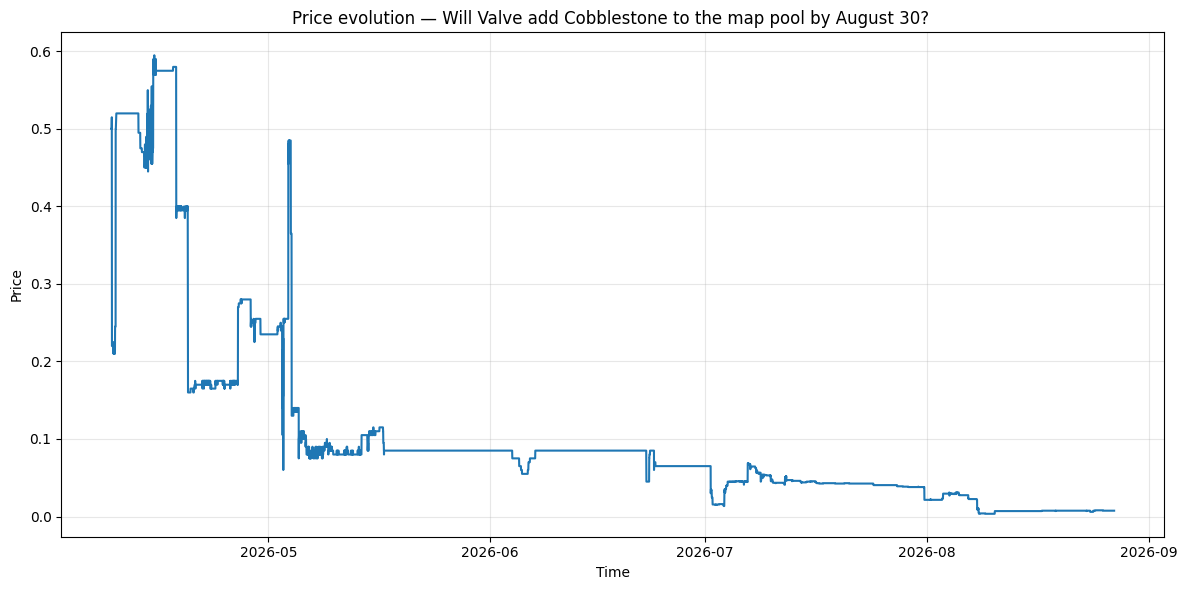

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Player/token you want
market_index = 2501

# Filter to this player
player_df = price_history_df[price_history_df["market_index"] == market_index].copy()

# Convert timestamp
player_df["timestamp"] = pd.to_datetime(player_df["timestamp"], utc=True)

# Sort chronologically
player_df = player_df.sort_values("timestamp")
question = player_df.iloc[0]["question"]
# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    player_df["timestamp"],
    player_df["price"],
    linewidth=1.5
)

plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"Price evolution — {question}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
columns = [
    "Open time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close time",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "Ignore"
]
eth_spot = pd.read_csv(r"C:\Users\brian\Desktop\ETHUSDT-5m-2026-07.csv", header=None,
    names=columns)
eth_spot["Open time"] = pd.to_datetime(eth_spot["Open time"], unit="us", utc=True).astype("datetime64[ms, UTC]")
eth_spot = eth_spot.rename(columns={
    "Open time": "timestamp"
})
eth_spot

,timestamp,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2026-07-01 00:00:00+00:00,1572.00,1574.90,1572.00,1574.89,1027.9291,1782864299999999,1.617077e+06,10286,558.8982,879413.077314,0
1,2026-07-01 00:05:00+00:00,1574.88,1575.43,1572.40,1572.66,423.1894,1782864599999999,6.662777e+05,5066,243.7465,383755.586836,0
2,2026-07-01 00:10:00+00:00,1572.65,1574.86,1572.65,1574.06,677.9353,1782864899999999,1.066965e+06,6295,511.4244,804925.835289,0
3,2026-07-01 00:15:00+00:00,1574.06,1575.39,1570.51,1570.51,285.7142,1782865199999999,4.493991e+05,3479,141.2795,222283.326172,0
4,2026-07-01 00:20:00+00:00,1570.52,1571.55,1568.31,1568.73,535.4685,1782865499999999,8.404076e+05,5142,214.7103,337004.095073,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8923,2026-07-31 23:35:00+00:00,1864.16,1864.18,1863.34,1863.92,116.3118,1785541199999999,2.167966e+05,2097,63.0753,117561.998593,0
8924,2026-07-31 23:40:00+00:00,1863.91,1864.12,1863.27,1863.61,114.0950,1785541499999999,2.126254e+05,2092,75.2980,140318.907203,0
8925,2026-07-31 23:45:00+00:00,1863.61,1863.74,1862.19,1862.19,225.3369,1785541799999999,4.197900e+05,3389,82.7456,154164.207555,0
8926,2026-07-31 23:50:00+00:00,1862.20,1863.28,1860.95,1861.76,365.4604,1785542099999999,6.806170e+05,5815,104.5064,194609.703588,0


In [44]:
from pathlib import Path
import pandas as pd
columns = [
    "Open time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close time",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "Ignore"
]
folder = Path(r"C:\Users\brian\Desktop")
print("Folder exists:", folder.exists())
print("Folder:", folder)
files = sorted(folder.glob("ETHUSDT*.csv"))

dfs = []

for file in files:
    # Extract meeting date from filename

    eth_spot = pd.read_csv(file, header=None,
    names=columns)

    eth_spot["Open time"] = pd.to_datetime(eth_spot["Open time"], unit="us", utc=True).astype("datetime64[ms, UTC]")
    eth_spot = eth_spot.rename(columns={
        "Open time": "timestamp"
    })

    dfs.append(eth_spot)

eth = pd.concat(dfs, ignore_index=True)
eth = eth.sort_values("timestamp")
eth.to_parquet("eth_spot_historical_price.parquet")

Folder exists: True
Folder: C:\Users\brian\Desktop


In [46]:
eth_spot = pd.read_parquet("eth_spot_historical_price.parquet")
eth_spot

,timestamp,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2025-10-01 00:00:00+00:00,4145.15,4151.41,4144.65,4151.41,1038.4316,1759277099999999,4.308127e+06,17178,723.1062,2.999765e+06,0
1,2025-10-01 00:05:00+00:00,4151.41,4152.37,4148.33,4149.14,620.0314,1759277399999999,2.573722e+06,9562,324.4493,1.346717e+06,0
2,2025-10-01 00:10:00+00:00,4149.14,4149.25,4144.35,4145.84,670.3296,1759277699999999,2.779812e+06,7880,262.0305,1.086663e+06,0
3,2025-10-01 00:15:00+00:00,4145.85,4147.04,4140.17,4144.72,719.1728,1759277999999999,2.979700e+06,13383,251.3857,1.041454e+06,0
4,2025-10-01 00:20:00+00:00,4144.72,4145.35,4136.04,4137.47,1241.2362,1759278299999999,5.136679e+06,13317,294.1102,1.216943e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87547,2026-07-31 23:35:00+00:00,1864.16,1864.18,1863.34,1863.92,116.3118,1785541199999999,2.167966e+05,2097,63.0753,1.175620e+05,0
87548,2026-07-31 23:40:00+00:00,1863.91,1864.12,1863.27,1863.61,114.0950,1785541499999999,2.126254e+05,2092,75.2980,1.403189e+05,0
87549,2026-07-31 23:45:00+00:00,1863.61,1863.74,1862.19,1862.19,225.3369,1785541799999999,4.197900e+05,3389,82.7456,1.541642e+05,0
87550,2026-07-31 23:50:00+00:00,1862.20,1863.28,1860.95,1861.76,365.4604,1785542099999999,6.806170e+05,5815,104.5064,1.946097e+05,0


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_parquet("crypto_price_history_df.parquet")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick one market index
market_index = 587

# Filter to that index
df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df_index.sort_values("timestamp")

merged = pd.merge_asof(
    df_index,
    eth_spot.sort_values("timestamp"),
    on="timestamp",
    direction="backward",
    tolerance=pd.Timedelta("5min")
)

merged = merged[merged["Open"] > 0]

merged["eth_return_10m"] = (
    np.log(merged["Close"])
    .diff(2)
)

merged["eth_return_20m"] = (
    np.log(merged["Close"])
    .diff(4)
)

merged["eth_return_30m"] = (
    np.log(merged["Close"])
    .diff(6)
)

intervals = [10, 20, 30, 60, 120, 180, 1440]

for minutes in intervals:
    steps = minutes // 10
    print(steps)

    merged[f"yes_future_{minutes}m"] = (
        merged["price"].shift(-steps)
    )

    merged[f"yes_change_{minutes}m"] = (
        merged[f"yes_future_{minutes}m"] - merged["price"]
    )
merged

1
2
3
6
12
18
144


,timestamp,price,market_index,question,token_id,Open,High,Low,Close,Volume,...,yes_future_30m,yes_change_30m,yes_future_60m,yes_change_60m,yes_future_120m,yes_change_120m,yes_future_180m,yes_change_180m,yes_future_1440m,yes_change_1440m
0,2025-11-24 19:50:19+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2958.64,2965.48,2956.81,2957.74,1177.4771,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
1,2025-11-24 20:00:07+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2959.00,2965.60,2954.22,2956.53,1393.1693,...,0.445,0.0,0.445,0.0,0.45,0.005,0.455,0.010,0.495,0.05
2,2025-11-24 20:10:06+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2968.26,2987.00,2967.17,2976.22,4601.1598,...,0.445,0.0,0.445,0.0,0.45,0.005,0.455,0.010,0.495,0.05
3,2025-11-24 20:20:06+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2979.19,2982.44,2975.62,2976.86,1282.7656,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
4,2025-11-24 20:30:07+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2978.51,2978.77,2970.84,2974.50,1058.2884,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34994,2026-07-31 23:10:10+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1862.99,1863.58,1862.39,1862.45,292.9915,...,0.486,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34995,2026-07-31 23:20:14+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1863.68,1864.65,1863.30,1863.50,276.7017,...,0.486,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34996,2026-07-31 23:30:12+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1864.05,1864.77,1863.55,1864.17,111.8501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34997,2026-07-31 23:40:11+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1863.91,1864.12,1863.27,1863.61,114.0950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
import statsmodels.api as sm
models = {}

for horizon in [10, 20, 30, 60, 120, 180, 1440]:
    test = merged[
        ["eth_return_10m", f"yes_change_{horizon}m"]
    ].dropna()

    X = sm.add_constant(test["eth_return_10m"])
    y = test[f"yes_change_{horizon}m"]

    model = sm.OLS(y, X).fit()
    models[horizon] = model.params.iloc[1]
    
    print(f"\n{horizon}m")
    print(f"beta: {model.params.iloc[1]:.6f}")
    print(f"t-stat: {model.tvalues.iloc[1]:.3f}")
    print(f"p-value: {model.pvalues.iloc[1]:.6f}")
    print(f"R²: {model.rsquared:.4f}")


10m
beta: -0.124579
t-stat: -16.158
p-value: 0.000000
R²: 0.0074

20m
beta: -0.184855
t-stat: -19.725
p-value: 0.000000
R²: 0.0110

30m
beta: -0.229073
t-stat: -21.308
p-value: 0.000000
R²: 0.0128

60m
beta: -0.334624
t-stat: -23.918
p-value: 0.000000
R²: 0.0161

120m
beta: -0.417629
t-stat: -22.966
p-value: 0.000000
R²: 0.0149

180m
beta: -0.515165
t-stat: -23.643
p-value: 0.000000
R²: 0.0157

1440m
beta: -0.829121
t-stat: -14.741
p-value: 0.000000
R²: 0.0062


In [ ]:
def fee(price):
    return 0.07 * price * (1 - price)

def sortino(x, target=0):
    x = pd.Series(x).dropna()

    downside = np.minimum(x - target, 0)

    downside_dev = np.sqrt(
        np.mean(downside ** 2)
    )

    if downside_dev == 0:
        return np.nan

    return (
        x.mean() - target
    ) / downside_dev

spread = 0.01
half_spread = spread / 2

thresholds = [
    0.005,
    0.01,
    0.015,
    0.02,
    0.03,
    0.05,
    0.10,
    0.20
]

results = []

for threshold in thresholds:

    for horizon in [10, 20, 30, 60, 120, 180, 1440]:

        beta = models[horizon]
        
        s = merged.copy()

        # --------------------------------
        # SIGNAL
        # --------------------------------

        s["predicted_yes_change"] = (
            beta * s["eth_return_10m"]
        )

        s["signal"] = 0

        s.loc[
            s["predicted_yes_change"] > threshold,
            "signal"
        ] = 1       # BUY YES

        s.loc[
            s["predicted_yes_change"] < -threshold,
            "signal"
        ] = -1      # BUY NO
    
        # --------------------------------
        # ONLY TRADE SIGNALS
        # --------------------------------
        s = s[s["signal"] != 0].copy()

        s["entry_price"] = np.where(
            s["signal"] == 1,
            s["price"] + half_spread,
            1 - s["price"] + half_spread
        )

        s["exit_price"] = np.where(
            s["signal"] == 1,
            s[f"yes_future_{horizon}m"] - half_spread,
            1 - s[f"yes_future_{horizon}m"] - half_spread
        )

        s["entry_fee"] = fee(s["entry_price"])
        s["exit_fee"] = fee(s["exit_price"])

        # --------------------------------
        # GROSS P&L
        # --------------------------------

        s["gross_pnl"] = (
            s["exit_price"]
            - s["entry_price"]
        )

        # --------------------------------
        # NET P&L
        # --------------------------------

        s["net_pnl"] = (
            s["gross_pnl"]
            - s["entry_fee"]
            - s["exit_fee"]
        )

        # --------------------------------
        # RETURN
        # --------------------------------

        s["return"] = (
            s["net_pnl"]
            / s["entry_price"]
        )

        x = s["return"].dropna()

        results.append({
            "threshold": threshold,
            "horizon": horizon,
            "N": len(x),
            "mean_return": x.mean(),
            "median_return": x.median(),
            "win_rate": (x > 0).mean(),
            "sortino": sortino(x),
            "total_pnl": s["net_pnl"].sum()
        })

results_df = pd.DataFrame(results)
results_df
# Small and moderate shocks exhibit statistically negative subsequent price changes, but the edge is too small to overcome transaction costs. Very large shocks may contain a tradable mean-reversion signal, particularly at longer horizons.

# “I started with the hypothesis that ETH spot movements should lead repricing in related Polymarket contracts. 
# The intuition was that the underlying market should incorporate information faster than a relatively less liquid prediction market, creating a short-lived relative-value opportunity.
# I tested this across different price thresholds and horizons and then evaluated the resulting trades rather than just looking at correlation. 
# The results were disappointing: the larger-sample regions were generally unprofitable, and the positive results tended to occur in very small samples. 
# After incorporating execution considerations, I couldn't find evidence of a stable economically meaningful edge.

# The important thing I learned was that a plausible economic relationship isn't necessarily a tradable signal. 
# I had to distinguish between correlation, statistical predictability, and actual executable PnL.
#  I also found that the contract's nonlinear payoff and dependence on volatility and time-to-expiry made the relationship with spot much less straightforward than I initially assumed.”

# That's a very solid answer.
# And if they push:
# “So what would you do next?”
# That's where you can really impress them.
# I'd say:
# “I'd decompose the problem rather than immediately adding more ML. 
# First I'd estimate the conditional sensitivity of the contract to spot, volatility and time-to-expiry. 
# Then I'd test whether residual repricing after controlling for those variables is predictable. 
# I'd also explicitly model bid-ask, available liquidity and execution latency. 
# If the residual isn't statistically or economically significant out of sample, I'd stop pursuing that hypothesis rather than optimize it further.”


,threshold,horizon,N,mean_return,median_return,win_rate,sortino,total_pnl
0,0.005,10,8,-0.037889,-0.060597,0.250000,-0.509456,-0.134950
1,0.005,20,46,-0.062995,-0.060597,0.108696,-0.749953,-1.205300
2,0.005,30,107,-0.060333,-0.064697,0.121495,-0.703527,-2.852051
3,0.005,60,318,-0.060730,-0.066028,0.097484,-0.684359,-9.065059
4,0.005,120,588,-0.065518,-0.065800,0.093537,-0.673114,-18.149052
5,0.005,180,1021,-0.069146,-0.068600,0.090108,-0.689016,-31.388192
6,0.005,1440,2767,-0.058066,-0.069138,0.214312,-0.410505,-85.570641
7,0.010,10,0,NaN,NaN,NaN,NaN,0.000000
8,0.010,20,1,-0.079004,-0.079004,0.000000,-1.000000,-0.026071
9,0.010,30,4,-0.062098,-0.062361,0.000000,-0.838165,-0.086687


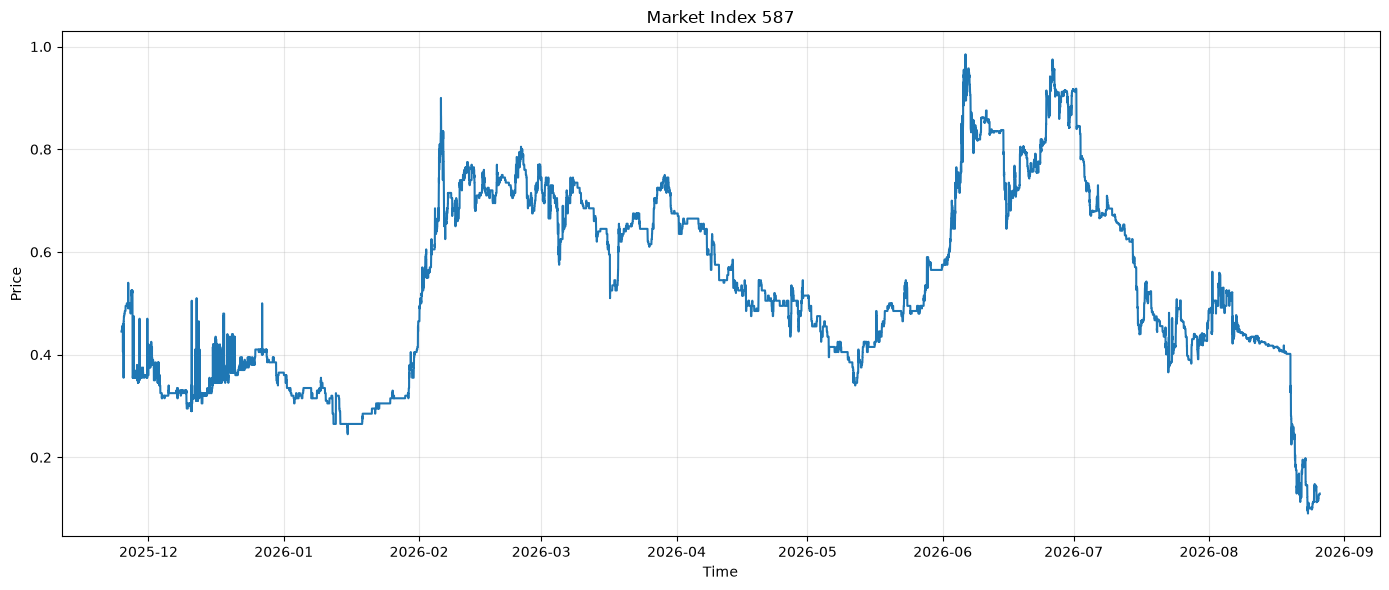

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("crypto_price_history_df.parquet")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick one market index
market_index = 587

# Filter to that index
df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df_index.sort_values("timestamp")

# Plot price over time
plt.figure(figsize=(14, 6))
plt.plot(df_index["timestamp"], df_index["price"])

plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"Market Index {market_index}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

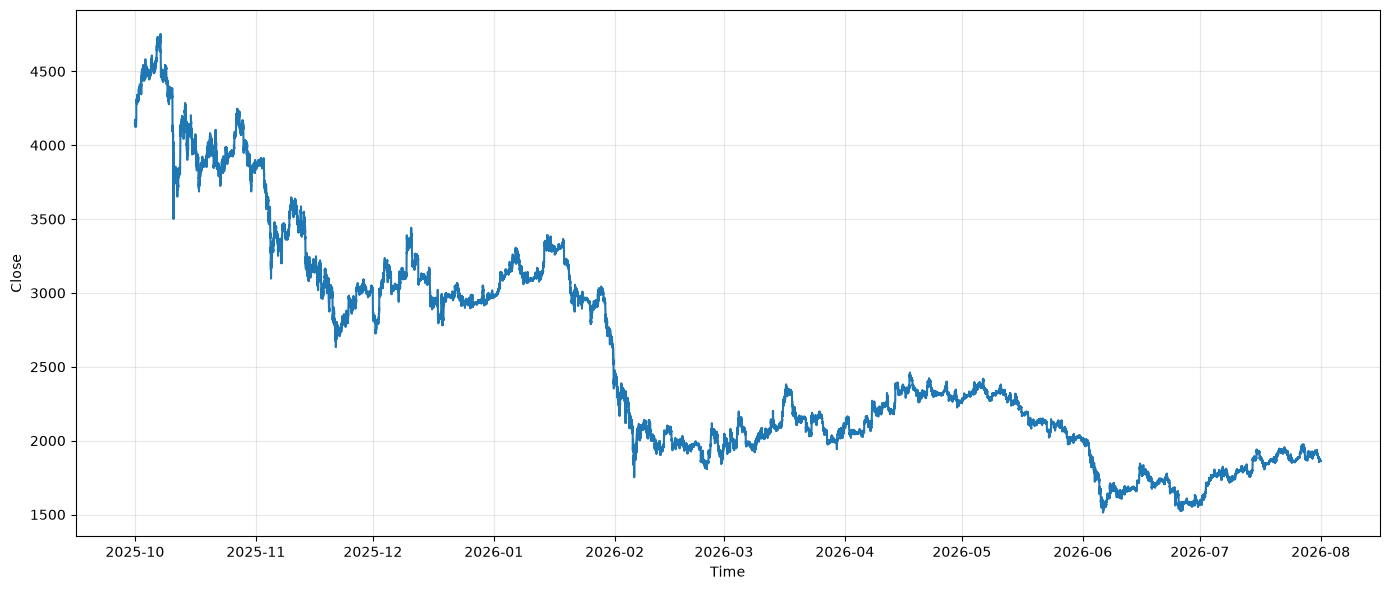

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

df = eth_spot

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# # Pick one market index
# market_index = 587

# # Filter to that index
# df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df.sort_values("timestamp")

# Plot price over time
plt.figure(figsize=(14, 6))
plt.plot(df_index["timestamp"], df_index["Close"])

plt.xlabel("Time")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
sum_series = (
    price_history_df.groupby("timestamp")["price"]
    .sum()
)

gender
Men      1.037
Women    1.086
Name: yes_ask, dtype: object

In [28]:
import time
from datetime import datetime, timezone
import requests
def get_price_history(
    token_id: str,
    start_ts: int,
    end_ts: int,
    interval="1m",
    fidelity=10,
):
    url = "https://clob.polymarket.com/prices-history"

    params = {
        "market": token_id,
        "startTs": start_ts,
        "endTs": end_ts,
        "interval": interval,
        "fidelity": fidelity,
    }

    r = requests.get(url, params=params, timeout=30)

    if not r.ok:
        raise RuntimeError(
            f"{r.status_code}: {r.text}"
        )

    return r.json()["history"]


def get_history_chunked(
    token_id: str,
    start_ts: int,
    end_ts: int,
    chunk_days=1,
):
    all_history = []

    chunk_seconds = chunk_days * 24 * 60 * 60

    current = start_ts

    while current < end_ts:
        chunk_end = min(
            current + chunk_seconds,
            end_ts
        )

        print(
            datetime.fromtimestamp(
                current, tz=timezone.utc
            ),
            "->",
            datetime.fromtimestamp(
                chunk_end, tz=timezone.utc
            )
        )

        history = get_price_history(
            token_id,
            current,
            chunk_end,
        )

        all_history.extend(history)

        current = chunk_end

    # Convert to dataframe
    df = pd.DataFrame(all_history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(
        df["t"],
        unit="s",
        utc=True
    )

    df["price"] = df["p"].astype(float)

    df = df[
        ["timestamp", "price"]
    ]

    # Remove duplicate timestamps caused by chunk boundaries
    df = (
        df
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return df
    
df = markets_df.copy()

now_ts = int(time.time())

all_market_history = {}

for idx, row in df.iterrows():

    token_id = row["yes_token"]

    # Convert createdAt -> Unix timestamp
    created_at = pd.to_datetime(row["createdAt"])
    start_ts = int(created_at.timestamp())

    print("\n" + "=" * 80)
    print(f"Market: {row['question']}")
    print(f"Created: {created_at}")
    print(
        f"Start: {datetime.fromtimestamp(start_ts, tz=timezone.utc)}"
    )

    try:
        history = get_history_chunked(
            token_id=token_id,
            start_ts=start_ts,
            end_ts=now_ts,
            chunk_days=15
        )

        # Keep market metadata
        history["market_index"] = idx
        history["question"] = row["question"]
        history["token_id"] = token_id

        all_market_history[idx] = history

        print(f"Downloaded {len(history):,} observations")

    except Exception as e:
        print(f"ERROR: {e}")

price_history_df = pd.concat(
    all_market_history.values(),
    ignore_index=True
)

print(price_history_df.head())
print(price_history_df.shape)


Market: Will Carlos Alcaraz win the 2026 Men's US Open?
Created: 2026-01-02 17:59:43.884641+00:00
Start: 2026-01-02 17:59:43+00:00
2026-01-02 17:59:43+00:00 -> 2026-01-17 17:59:43+00:00
2026-01-17 17:59:43+00:00 -> 2026-02-01 17:59:43+00:00
2026-02-01 17:59:43+00:00 -> 2026-02-16 17:59:43+00:00
2026-02-16 17:59:43+00:00 -> 2026-03-03 17:59:43+00:00
2026-03-03 17:59:43+00:00 -> 2026-03-18 17:59:43+00:00
2026-03-18 17:59:43+00:00 -> 2026-04-02 17:59:43+00:00
2026-04-02 17:59:43+00:00 -> 2026-04-17 17:59:43+00:00
2026-04-17 17:59:43+00:00 -> 2026-05-02 17:59:43+00:00
2026-05-02 17:59:43+00:00 -> 2026-05-17 17:59:43+00:00
2026-05-17 17:59:43+00:00 -> 2026-06-01 17:59:43+00:00
2026-06-01 17:59:43+00:00 -> 2026-06-16 17:59:43+00:00
2026-06-16 17:59:43+00:00 -> 2026-07-01 17:59:43+00:00
2026-07-01 17:59:43+00:00 -> 2026-07-16 17:59:43+00:00
2026-07-16 17:59:43+00:00 -> 2026-07-31 17:59:43+00:00
2026-07-31 17:59:43+00:00 -> 2026-08-15 17:59:43+00:00
2026-08-15 17:59:43+00:00 -> 2026-08-26 06:

In [48]:
price_history_df = pd.read_parquet("tennis_price_history_df.parquet")
price_history_df = (
    price_history_df.set_index("timestamp")
      .groupby("token_id")
      .resample("10min")
      .agg({
          "price": "last",
          "market_index": "first",
          "question": "first",
      })
      .reset_index()
)
price_history_df

,token_id,timestamp,price,market_index,question
0,1002087609790068157008213655546239890485855419...,2026-01-02 21:00:00+00:00,0.460,925.0,Will Donna Vekic win the 2026 Women’s US Open?
1,1002087609790068157008213655546239890485855419...,2026-01-02 21:10:00+00:00,0.445,925.0,Will Donna Vekic win the 2026 Women’s US Open?
2,1002087609790068157008213655546239890485855419...,2026-01-02 21:20:00+00:00,0.410,925.0,Will Donna Vekic win the 2026 Women’s US Open?
3,1002087609790068157008213655546239890485855419...,2026-01-02 21:30:00+00:00,0.050,925.0,Will Donna Vekic win the 2026 Women’s US Open?
4,1002087609790068157008213655546239890485855419...,2026-01-02 21:40:00+00:00,0.050,925.0,Will Donna Vekic win the 2026 Women’s US Open?
...,...,...,...,...,...
1762670,9802550207568138353041385750563535019776718188...,2026-08-26 05:50:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762671,9802550207568138353041385750563535019776718188...,2026-08-26 06:00:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762672,9802550207568138353041385750563535019776718188...,2026-08-26 06:10:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762673,9802550207568138353041385750563535019776718188...,2026-08-26 06:20:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?


In [51]:
import numpy as np
import pandas as pd

df = price_history_df.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = (
    df[
        df["price"].between(0, 1)
    ]
    .sort_values(["token_id", "timestamp"])
    .copy()
)

# ---------------------------------------------------------
# 1. Resample to exact 10-minute intervals
# ---------------------------------------------------------

df = (
    df.set_index("timestamp")
      .groupby("token_id")["price"]
      .resample("10min")
      .last()
      .dropna()
      .reset_index()
)

# ---------------------------------------------------------
# 2. Logit transform
# ---------------------------------------------------------

eps = 0.001

p = df["price"].clip(eps, 1 - eps)

df["logit"] = np.log(p / (1 - p))


# ---------------------------------------------------------
# 3. Rolling 24-hour z-score
# ---------------------------------------------------------

# 24 hours = 144 ten-minute observations
window = 144

g = df.groupby("token_id")["logit"]

df["rolling_mean"] = (
    g.transform(
        lambda x:
        x.rolling(
            window,
            min_periods=72
        ).mean()
    )
)

df["rolling_std"] = (
    g.transform(
        lambda x:
        x.rolling(
            window,
            min_periods=72
        ).std()
    )
)

df["zscore"] = (
    (df["logit"] - df["rolling_mean"])
    / df["rolling_std"]
)


# ---------------------------------------------------------
# 4. Future logit changes
# ---------------------------------------------------------

g_logit = df.groupby("token_id")["logit"]

for name, periods in {
    "1h": 6,
    "6h": 36,
    "24h": 144,
    "3d": 432,
}.items():

    df[f"future_logit_{name}"] = (
        g_logit.shift(-periods)
        - df["logit"]
    )

In [53]:
for horizon in ["1h", "6h", "24h", "3d"]:

    signal = df["zscore"] < -2

    result = df.loc[
        signal,
        f"future_logit_{horizon}"
    ].dropna()

    print(
        f"{horizon:>4}",
        f"N={len(result):>7,}",
        f"mean={result.mean():+.5f}",
        f"median={result.median():+.5f}",
        f"win={(result > 0).mean():.3f}"
    )

for horizon in ["1h", "6h", "24h", "3d"]:

    signal = df["zscore"] > 2

    result = df.loc[
        signal,
        f"future_logit_{horizon}"
    ].dropna()

    print(
        f"{horizon:>4}",
        f"N={len(result):>7,}",
        f"mean={result.mean():+.5f}",
        f"median={result.median():+.5f}",
        f"win={(result > 0).mean():.3f}"
    )

  1h N= 84,245 mean=+0.00403 median=+0.00000 win=0.136
  6h N= 84,244 mean=-0.00364 median=+0.00000 win=0.233
 24h N= 83,869 mean=-0.01005 median=+0.00000 win=0.326
  3d N= 83,349 mean=-0.04760 median=+0.00000 win=0.357
  1h N= 56,715 mean=-0.03103 median=+0.00000 win=0.101
  6h N= 56,579 mean=-0.06682 median=+0.00000 win=0.159
 24h N= 56,334 mean=-0.12177 median=-0.02032 win=0.233
  3d N= 55,592 mean=-0.17258 median=-0.06504 win=0.267


In [112]:
market_index = 875

# Filter to this player
player_df = price_history_df[price_history_df["market_index"] == market_index].copy()

alcaraz = (
    price_history_df[
        price_history_df["question"]
        == "Will Carlos Alcaraz win the 2026 Men's US Open?"
    ]
    .copy()
)

alcaraz["timestamp"] = pd.to_datetime(
    alcaraz["timestamp"],
    utc=True
)

alcaraz["price"] = pd.to_numeric(
    alcaraz["price"],
    errors="coerce"
)

alcaraz = (
    alcaraz
    .sort_values("timestamp")
    .reset_index(drop=True)
)

alcaraz.head()

alcaraz["change"] = (
    alcaraz["price"].diff()
)

alcaraz["pct_change"] = (
    alcaraz["price"].pct_change()
)

alcaraz[
    ["timestamp", "price", "change", "pct_change"]
].head(30)

,timestamp,price,change,pct_change
0,2026-01-02 21:00:00+00:00,0.500,NaN,NaN
1,2026-01-02 21:10:00+00:00,0.485,-0.015,-0.030000
2,2026-01-02 21:20:00+00:00,0.465,-0.020,-0.041237
3,2026-01-02 21:30:00+00:00,0.455,-0.010,-0.021505
4,2026-01-02 21:40:00+00:00,0.470,0.015,0.032967
5,2026-01-02 21:50:00+00:00,0.560,0.090,0.191489
6,2026-01-02 22:00:00+00:00,0.560,0.000,0.000000
7,2026-01-02 22:10:00+00:00,0.545,-0.015,-0.026786
8,2026-01-02 22:20:00+00:00,0.525,-0.020,-0.036697
9,2026-01-02 22:30:00+00:00,0.510,-0.015,-0.028571
